# CLUSTERING (Unsupervised)

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv(r'C:\Users\moham\Desktop\Data Science\BeCode\becode_projects\immo-eliza\data\processed\listings_with_distance_clean.csv')

In [50]:
df.columns

Index(['locality', 'region', 'zip_code', 'property_type', 'subtype',
       'price_eur', 'type_of_sale', 'num_rooms', 'living_area_m2',
       'fully_equipped_kitchen', 'furnished', 'terrace', 'terrace_area_m2',
       'garden', 'garden_area_m2', 'land_surface_m2', 'num_facades',
       'swimming_pool', 'state_of_building', 'num_bathrooms', 'dist_train_km',
       'dist_bus_km'],
      dtype='str')

The goal is to create clusters based on house vs apartment characteristics.
For that, we drop all strings, categories, and geographic identifiers

In [51]:
'''
to drop or not to drop land_surface_m2?
In the very first data_cleaning for analysis, 
i filled the NANs of land_surface_m2 of apartments with 0
thinking that apartments do not really have land surface.
Now it became a small hurdle because models see 0 
all apts and use it as a strong mathematical anchor

Will have to try with and without
'''

cols_to_drop = ['locality', 'region', 'zip_code', 'property_type', 
                'subtype', 'type_of_sale', 'fully_equipped_kitchen', 
                'furnished', 'state_of_building', 
                'dist_train_km', 'dist_bus_km']

X = df.drop(columns=cols_to_drop)




In [52]:


X_features = ['num_rooms', 'living_area_m2', 'terrace', 'terrace_area_m2', 
              'garden', 'garden_area_m2', 'land_surface_m2', 'num_facades', 
              'swimming_pool','num_bathrooms', 'price_eur'
]
X.columns

Index(['price_eur', 'num_rooms', 'living_area_m2', 'terrace',
       'terrace_area_m2', 'garden', 'garden_area_m2', 'land_surface_m2',
       'num_facades', 'swimming_pool', 'num_bathrooms'],
      dtype='str')

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

preprocessor = Pipeline(steps=[
            #('imputer', KNNImputer(n_neighbors=5, weights='distance')),
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
    ])

# Prepare the Data (We do this BEFORE the loop to save massive compute time)
X_prepro = preprocessor.fit_transform(X)




The Elbow Method to evaluate how many K values for Kmeans model

To find the perfect balance, we use the Elbow Method. We test $K=2$, then 3, then 4, up to 10. We plot the Inertia on a graph. The line will drop rapidly at first, and then slowly flatten out. The exact point where it stops dropping rapidly (the "Elbow") is the mathematically optimal number of clusters for your data.


In [54]:
'''
inertia is the sum of all distances of every property from the Centroid (pin)
'''

inertia_values = []
K_range = range(2, 11)

print("Running K-Means... this will take a few seconds.")
for k in K_range:
    # n_init=10 means the algorithm will drop the pins 10 different times 
    # and keep the best layout to avoid bad random luck.
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_prepro)
    inertia_values.append(kmeans.inertia_)


Running K-Means... this will take a few seconds.


Plotting the Elbow

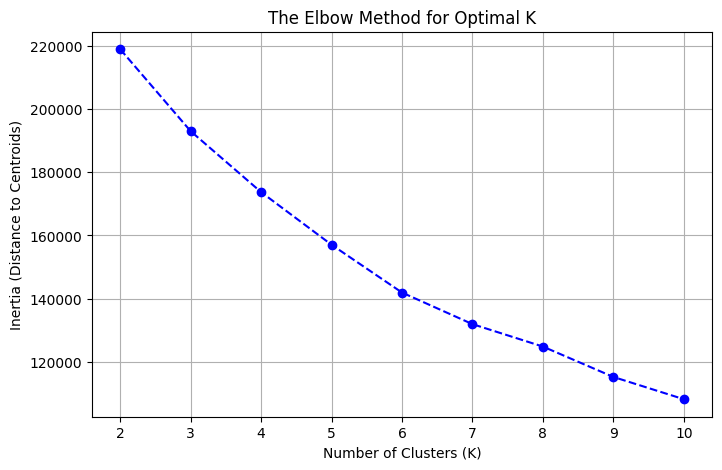

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Distance to Centroids)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

There is no clear elbow, it's a smooth curve...

We could still check where the steepness starts to flatten out:

From $K=2$ to $K=3$, there is a decent drop.

From $K=3$ to $K=4$, it’s still dropping.

Around $K=4$ or $K=5$, the line starts to become more "linear" 

Usually, in a plot like this, $K=3$ or $K=4$ is the safest bet. It gives you enough complexity to find "Small," "Medium," and "Large" properties without over-complicating things.

Why did this happen?

The Elbow Method only works perfectly when your data naturally forms tight, isolated islands in space. But real estate isn't like that. It is a continuous spectrum. A 90m² apartment blends smoothly into a 100m² apartment, which blends into a 110m² small house. Because the data is one giant, overlapping blob, K-Means is just arbitrarily slicing the blob into smaller and smaller pieces, so the Inertia drops steadily without a sharp break.

When the Elbow Method fails, Data Scientists do not guess. We bring in the lie-detector test for clustering: The Silhouette Score.

The Next Level: Silhouette Score

Inertia only measures one thing: Cohesion (how tight the clusters are). It doesn't care if the clusters are sitting right on top of each other.

The Silhouette Score is superior because it measures two things simultaneously:

1. Cohesion ($a$): How close a property is to the other properties in its own cluster. (We want this distance to be tiny).
2. Separation ($b$): How close a property is to the properties in the next closest cluster. (We want this distance to be huge).
 
The Math: For every single property, the algorithm calculates:

$$Silhouette = \frac{b - a}{\max(a, b)}$$

The Score (The -1 to +1 Scale):

Unlike Inertia (which is a random massive number), the Silhouette Score is strictly bound between -1 and 1.
 
* Near +1: Flawless. The property is tightly packed with its friends and miles away from the nearest other cluster.
* Near 0: Ambiguous. The property is sitting exactly on the border between two clusters.
* Near -1: Fatal Error. The property has likely been assigned to the wrong cluster.
  
  Instead of looking for a subjective "elbow" on a graph, we just calculate the average Silhouette Score for $K=2$, $K=3$, $K=4$, etc., and we literally just pick the $K$ that has the highest score.

In [56]:
from sklearn.metrics import silhouette_score

silhouette_values = []

print("Calculating Silhouette Scores... (Using safe sampling)")
for k in K_range:
    # 1. Fit the model just like before
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    clusters_labels = kmeans.fit_predict(X_prepro)

    # 2. Calculate the Silhouette Score safely using sample_size
    score = silhouette_score(X_prepro, clusters_labels, sample_size=5000, random_state=42)
    silhouette_values.append(score)

    print(f"K={k}: Silhouette Score = {score:.4f}")



Calculating Silhouette Scores... (Using safe sampling)
K=2: Silhouette Score = 0.6120
K=3: Silhouette Score = 0.2333
K=4: Silhouette Score = 0.2387
K=5: Silhouette Score = 0.2703
K=6: Silhouette Score = 0.2798
K=7: Silhouette Score = 0.2823
K=8: Silhouette Score = 0.2735
K=9: Silhouette Score = 0.3104
K=10: Silhouette Score = 0.3026


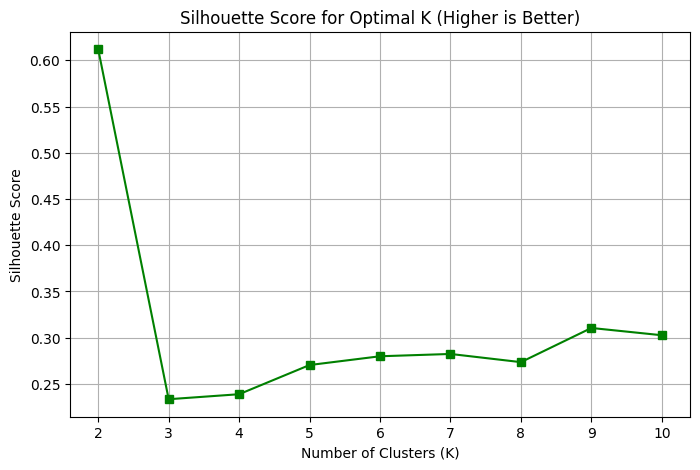

In [57]:
# 3. Plot the Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_values, marker='s', color='g')
plt.title('Silhouette Score for Optimal K (Higher is Better)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.grid(True)
plt.show()

BIG DISCOVERY:

KNNImputer VS SimpleImputer in Elbow plot and Silhouette Score plot:

When using KNNImputer, Elbow plot showed smooth curve. In Silhouette score plot, it showed 8 clusters as top K.

When using SimpleImputer, Elbow plot showed smooth curve. In Silhouette score plot, it shower 2 clusters as top K.

* SimpleImputer (Median) is the one that "over-smooths" or "clumps" the data. If 5,000 properties are missing a garden size, it forces all 5,000 of them to have exactly a 50m² garden. It artificially destroys variance and creates a massive, unnatural clump in the center of your data.

* KNNImputer preserves the noise and variance. It looks at the neighbors and gives one house a 200m² garden, and another a 20m² garden.

Belgian real estate data is a spectrum. There is no big gap in property sizes, they perfectly range from 20 m² to 1000 m².

This also tells us that KNNImputer tried to preserve the reality of real estate by creating 8 different clusters from the dataset

### NEXT STEP - DOUBLE EXPERIMENT

We will run two experiments side by side:

1. K = 2 with the SimpleImputer to check if the clusters are just Big vs Small or what we want from the beginning: House VS Apartments
   
2. K = 4 with the KNNImputer and see what clusters Kmeans finds for us 

In [58]:
# Rerunning previous loading code block to refresh data
import pandas as pd

df = pd.read_csv(r'C:\Users\moham\Desktop\Data Science\BeCode\becode_projects\immo-eliza\data\processed\listings_with_distance_clean.csv')



cols_to_drop = ['locality', 'region', 'zip_code', 'property_type',

                'subtype', 'type_of_sale', 'price_eur', 'fully_equipped_kitchen',

                'furnished', 'state_of_building',

                'dist_train_km', 'dist_bus_km']



X = df.drop(columns=cols_to_drop)

In [59]:

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [60]:
# ---------------------------------------------------------
# EXPERIMENT 1: K=2 (The SimpleImputer "Big vs Small" Test)
# ---------------------------------------------------------
print("Running Experiment 1 (K=2, SimpleImputer)...")

pipe_simple = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_simple_scaled = pipe_simple.fit_transform(X)

kmeans_2 = KMeans(n_clusters=2, n_init=10, random_state=42)
X_analyzed_2 = X.copy()
X_analyzed_2['Cluster_K2'] = kmeans_2.fit_predict(X_simple_scaled)

print("\n--- K=2 PROFILES (Median Values) ---")
display(X_analyzed_2.groupby('Cluster_K2').median().T)



Running Experiment 1 (K=2, SimpleImputer)...



--- K=2 PROFILES (Median Values) ---


Cluster_K2,0,1
num_rooms,4.0,3.0
living_area_m2,300.0,135.0
terrace,1.0,1.0
terrace_area_m2,36.0,8.0
garden,1.0,1.0
garden_area_m2,1000.0,0.0
land_surface_m2,1648.0,115.0
num_facades,4.0,3.0
swimming_pool,1.0,0.0
num_bathrooms,3.0,2.0


Experiment 1 lead to the expected:

The model failed to effectively separate Houses and Apartments

In [61]:
# ---------------------------------------------------------
# EXPERIMENT 2: K=4 (The KNNImputer "Market Persona" Test)
# ---------------------------------------------------------
print("\nRunning Experiment 2 (K=4, KNNImputer)... This will take a moment.")
pipe_knn = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5, weights='distance')),
    
])
X_knn_scaled = pipe_knn.fit_transform(X)

kmeans_4 = KMeans(n_clusters=4, n_init=10, random_state=42)
X_analyzed_4 = X.copy()
X_analyzed_4['Cluster_K4'] = kmeans_4.fit_predict(X_knn_scaled)

print("\n--- K=4 PROFILES (Median Values) ---")
display(X_analyzed_4.groupby('Cluster_K4').median().T)


Running Experiment 2 (K=4, KNNImputer)... This will take a moment.

--- K=4 PROFILES (Median Values) ---


Cluster_K4,0,1,2,3
num_rooms,2.0,6.0,3.0,4.0
living_area_m2,100.0,614.0,163.0,256.5
terrace,1.0,1.0,1.0,1.0
terrace_area_m2,5.0,19.0,13.0,40.0
garden,0.0,1.0,1.0,1.0
garden_area_m2,0.0,14022.0,200.0,750.0
land_surface_m2,0.0,23619.0,383.0,1281.0
num_facades,2.0,4.0,3.0,4.0
swimming_pool,0.0,0.0,0.0,1.0
num_bathrooms,1.0,5.0,2.0,2.0


Experiment 2 lead to 4 clusters, each with specific physical dimensions:

1. Cluster 0: The Classic Apartment. * The Math: 0m² land, 0m² garden, exactly      2 facades (front and back windows), 100m² living area, 2 rooms.

2. Cluster 1: The Standard Suburban House (Row/Semi-detached).
    * The Math: 382m² land, 200m² garden, 3 facades, 163m² living area, 3 rooms.

3. Cluster 2: The Luxury Villa.
    * The Math: 1296m² land, 750m² garden, 4 facades (freestanding), 259m² living area, 4 rooms... and every single one of them has a swimming pool (Median = 1.0).

4. Cluster 3: The Massive Estate / Farmhouse.
    * The Math: 17,470m² land (nearly 2 hectares!), 621m² living area, 7 rooms, 5.5 bathrooms.

### VISUALIZATION

Your dataset has 10 columns. That means K-Means drew its clusters in a 10-Dimensional hyperspace. Humans cannot look at a 10-dimensional graph.

To visualize this, we use a brilliant mathematical trick called PCA (Principal Component Analysis).

PCA acts like a giant shadow projector. It takes your 10-dimensional data cloud and "squishes" it flat onto a 2D piece of paper, trying its hardest to keep properties that were far apart in 10D far apart in 2D.

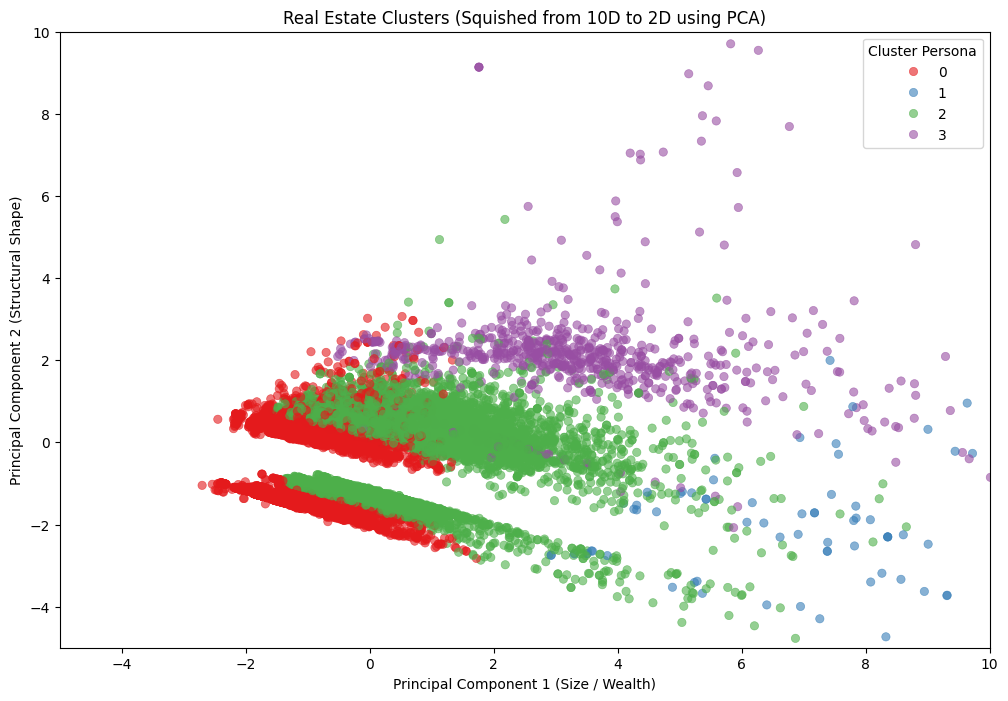

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Initialize PCA to squish 10 dimensions down to 2 dimensions
pca = PCA(n_components=2)

# 2. Fit and transform the SCALED data (We must use the exact math K-Means saw)
X_pca = pca.fit_transform(X_knn_scaled)

# 3. Create a clean DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = X_analyzed_4['Cluster_K4']

# 4. Draw the Graph
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='Set1', # Gives distinct, bright colors
    data=pca_df, 
    alpha=0.6,      # Makes dots slightly transparent so we can see overlaps
    edgecolor=None
)
plt.title('Real Estate Clusters (Squished from 10D to 2D using PCA)')
plt.xlabel('Principal Component 1 (Size / Wealth)')
plt.ylabel('Principal Component 2 (Structural Shape)')
plt.legend(title='Cluster Persona')
# Force the camera to zoom in on the core 99% of the data
# (You might need to tweak these numbers slightly based on your specific blob)
plt.xlim(-5, 10) 
plt.ylim(-5, 10)
plt.savefig('ImmoEliza dataset clustering visualization')
